In [2]:
import pandas as pd

df = pd.read_csv('/content/IMDB Dataset.csv')

# Display the first 5 rows
print(df.head())

                                              review sentiment
0  One of the other reviewers has mentioned that ...  positive
1  A wonderful little production. <br /><br />The...  positive
2  I thought this was a wonderful way to spend ti...  positive
3  Basically there's a family where a little boy ...  negative
4  Petter Mattei's "Love in the Time of Money" is...  positive


In [3]:
# dataset info
df.info()

# dataset shape
print(df.shape)

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 50000 entries, 0 to 49999
Data columns (total 2 columns):
 #   Column     Non-Null Count  Dtype 
---  ------     --------------  ----- 
 0   review     50000 non-null  object
 1   sentiment  50000 non-null  object
dtypes: object(2)
memory usage: 781.4+ KB
(50000, 2)


In [4]:
# Missing Values Count
print(df.isnull().sum())

review       0
sentiment    0
dtype: int64


 Sentiment Target counts
sentiment
positive    24884
negative    24698
Name: count, dtype: int64


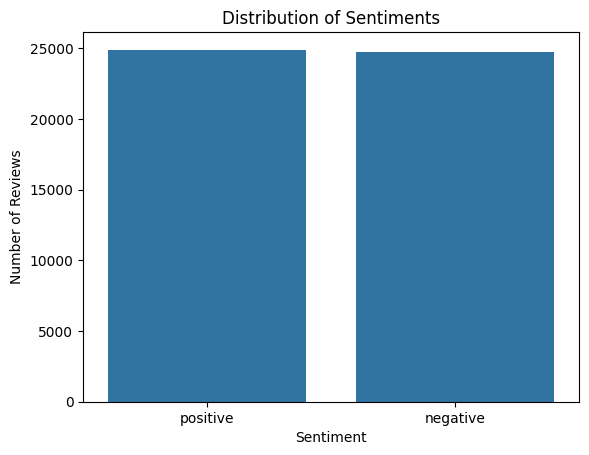

In [15]:
import matplotlib.pyplot as plt
import seaborn as sns

# Count the frequency of each sentiment class
print(" Sentiment Target counts")
print(df['sentiment'].value_counts())

# Visualize the distribution
sns.countplot(x='sentiment', data=df)
plt.title('Distribution of Sentiments')
plt.xlabel('Sentiment')
plt.ylabel('Number of Reviews')
plt.show()


Descriptive Statistics for Word Count 
count    50000.000000
mean       231.156940
std        171.343997
min          4.000000
25%        126.000000
50%        173.000000
75%        280.000000
max       2470.000000
Name: word_count, dtype: float64


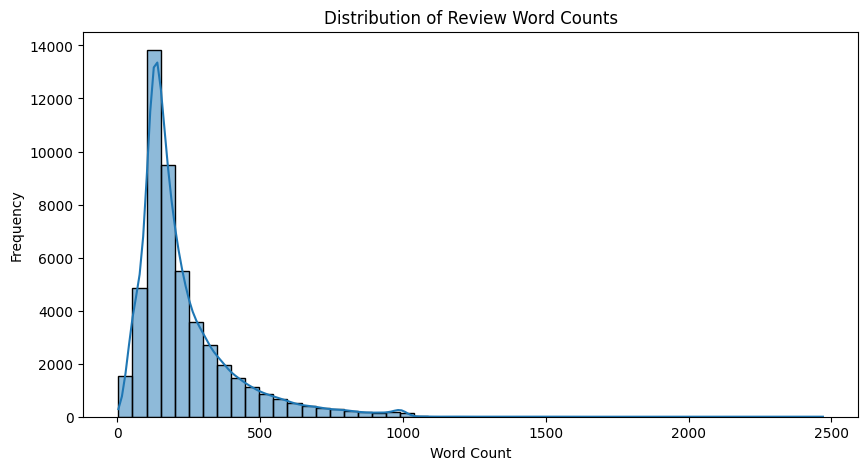

In [6]:
# Calculate word count for each review
df['word_count'] = df['review'].apply(lambda x: len(str(x).split()))

print("\nDescriptive Statistics for Word Count ")
print(df['word_count'].describe())

# Plot the distribution of word counts
plt.figure(figsize=(10, 5))
sns.histplot(df['word_count'], bins=50, kde=True)
plt.title('Distribution of Review Word Counts')
plt.xlabel('Word Count')
plt.ylabel('Frequency')
plt.show()


In [7]:
import numpy as np
from scipy import stats

# DATA QUALITY: DUPLICATE CHECK
print("\n--- Data Quality Assessment ---")
duplicates = df.duplicated().sum()
print(f"Duplicate rows found: {duplicates}")

if duplicates > 0:
    df = df.drop_duplicates()
    print(f"Dataset shape after removing duplicates: {df.shape}")


--- Data Quality Assessment ---
Duplicate rows found: 418
Dataset shape after removing duplicates: (49582, 3)


In [8]:
# FEATURE ENGINEERING
print("\n--- Feature Engineering ---")
df['char_count'] = df['review'].apply(len)
df['avg_word_length'] = df['char_count'] / (df['word_count'] + 1)

print(df[['word_count', 'char_count', 'avg_word_length']].describe())


--- Feature Engineering ---
         word_count    char_count  avg_word_length
count  49582.000000  49582.000000     49582.000000
mean     231.350167   1310.568230         5.597861
std      171.542020    990.762238         0.339620
min        4.000000     32.000000         2.228956
25%      126.000000    699.000000         5.376344
50%      173.000000    971.000000         5.587302
75%      281.000000   1592.000000         5.808081
max     2470.000000  13704.000000        13.035714


<Axes: ylabel='avg_word_length'>

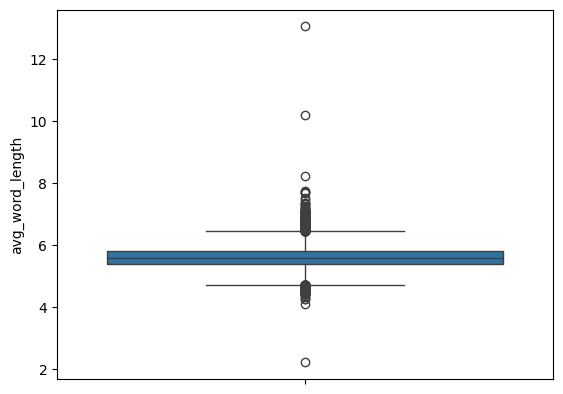

In [12]:
# Average Word Length Box Plot
sns.boxplot(y=df['avg_word_length'])

/tmp/ipykernel_1900/4143551436.py:4: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(x='sentiment', y='word_count', data=df, palette='Set2')


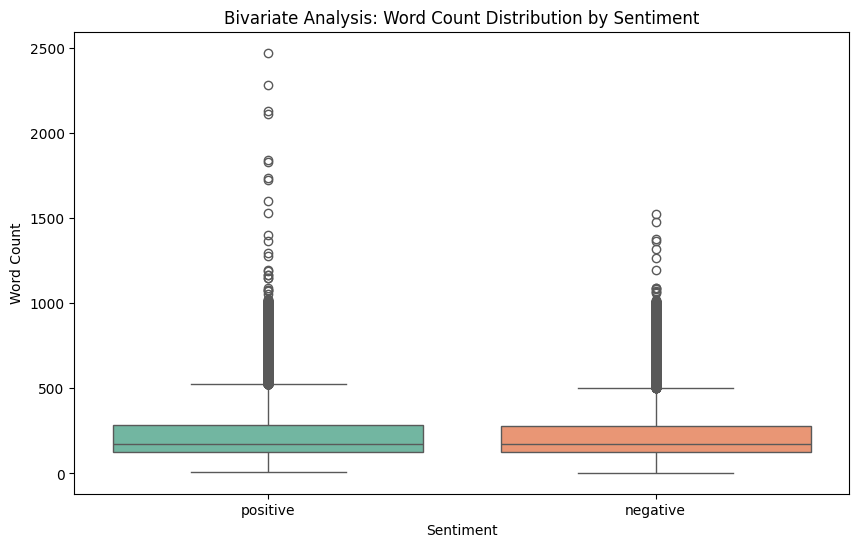

In [9]:
# BIVARIATE ANALYSIS
# compare Word Count vs Sentiment using a Box Plot
plt.figure(figsize=(10, 6))
sns.boxplot(x='sentiment', y='word_count', data=df, palette='Set2')
plt.title('Bivariate Analysis: Word Count Distribution by Sentiment')
plt.xlabel('Sentiment')
plt.ylabel('Word Count')
plt.show()-

<Axes: xlabel='word_count', ylabel='char_count'>

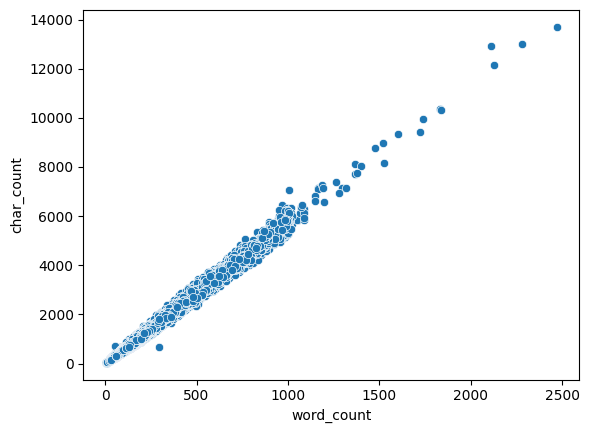

In [13]:
# Word Count vs Character Count Scatter Plot
sns.scatterplot(x='word_count', y='char_count', data=df)

<Axes: xlabel='sentiment', ylabel='word_count'>

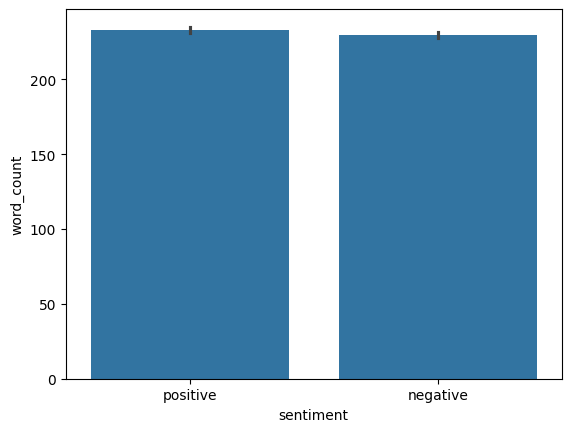

In [16]:
# Bar Chart of Average Word Count by Sentiment
sns.barplot(x='sentiment', y='word_count', data=df)

In [10]:
# OUTLIER DETECTION
print("\n--- Outlier Detection (Z-Score) ---")
z_scores = np.abs(stats.zscore(df['word_count']))
# A Z-score > 3 is a standard threshold for outliers
outliers = df[z_scores > 3]
print(f"Number of outliers (reviews with extreme word counts): {len(outliers)}")


--- Outlier Detection (Z-Score) ---
Number of outliers (reviews with extreme word counts): 1189


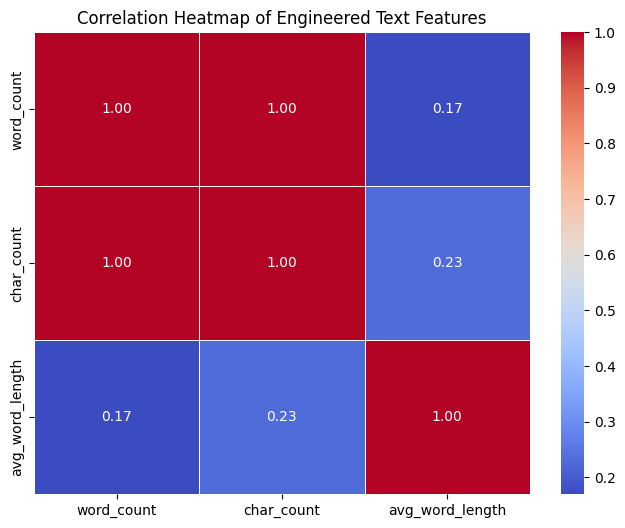

In [11]:
#  MULTIVARIATE / CORRELATION ANALYSIS
numerical_cols = ['word_count', 'char_count', 'avg_word_length']
corr_matrix = df[numerical_cols].corr()

plt.figure(figsize=(8, 6))
sns.heatmap(corr_matrix, annot=True, cmap='coolwarm', fmt=".2f", linewidths=0.5)
plt.title('Correlation Heatmap of Engineered Text Features')
plt.show()